# Chapter 14 — Singular Value Decomposition

## Learning Objectives

This notebook covers SVD, singular values, rank, rank-1 layers, explained variance, condition number, and pseudoinverse.

## Theoretical Explanation

SVD factors any matrix into `U @ Sigma @ V.T`. Unlike eigendecomposition, SVD applies to rectangular and singular matrices. Singular values quantify the strength of independent directions in the matrix. Nonzero singular values determine rank, and their ratio gives the condition number.

SVD is one of the most useful decompositions in data science because it supports compression, denoising, PCA, low-rank approximation, and pseudoinverse computation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. SVD Reconstruction and Rank

In [2]:
A = np.random.randn(6,4)
U, s, Vt = np.linalg.svd(A, full_matrices=False)
S = np.diag(s)
A_recon = U @ S @ Vt
print('A shape:', A.shape)
print('singular values:', np.round(s,3))
print('rank from singular values:', np.sum(s > 1e-10))
print('reconstruction error:', norm(A-A_recon))

A shape: (6, 4)
singular values: [3.493 2.324 1.928 1.008]
rank from singular values: 4
reconstruction error: 3.2673865500927995e-15


### Output Interpretation

SVD reconstructs the original matrix from orthogonal directions and singular values. The number of nonzero singular values equals the matrix rank.

## 2. Low-Rank Approximation

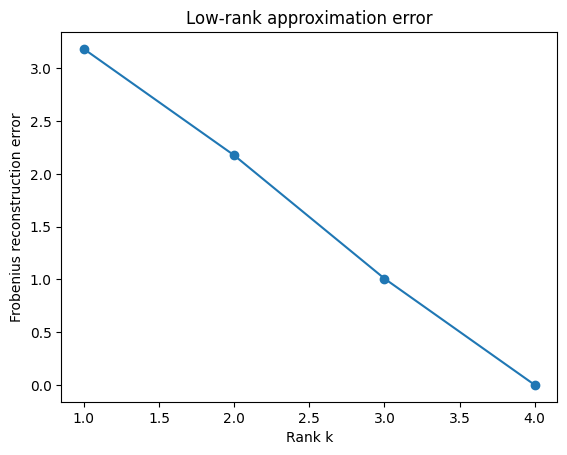

In [3]:
errors = []
for k in range(1, len(s)+1):
    Ak = U[:,:k] @ np.diag(s[:k]) @ Vt[:k,:]
    errors.append(norm(A-Ak,'fro'))
plt.plot(range(1,len(s)+1), errors, marker='o')
plt.xlabel('Rank k')
plt.ylabel('Frobenius reconstruction error')
plt.title('Low-rank approximation error')
plt.show()

### Output Interpretation

As more singular components are included, reconstruction error decreases. This illustrates why SVD is useful for compression and denoising.

## 3. Pseudoinverse from SVD

In [4]:
A_pinv = np.linalg.pinv(A)
S_inv = np.diag(1/s)
A_pinv_manual = Vt.T @ S_inv @ U.T
print('pseudoinverse difference:', norm(A_pinv - A_pinv_manual))
print('condition number:', s.max()/s.min())

pseudoinverse difference: 6.633474604680505e-17
condition number: 3.4650456513047523


### Output Interpretation

The SVD-based pseudoinverse matches NumPy's pseudoinverse. The condition number summarizes numerical sensitivity.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.